In [13]:
#All test files:
#1) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_2_1961.7s_RH661.032_x0.300_th0.000_5.00s_458795_waxs.tiff"
#2) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_6_2795.4s_RH-28.010_x0.300_th0.000_5.00s_458825_saxs.tiff"
#3) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_WAXSx-193_y22_x0.300_th0.000_5.00s_1000930_waxs.tiff"
#4) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_x0.000_y0.000_10.00s_988715_saxs.tiff"
#5) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_x0.000_y0.000_10.00s_988715_waxs.tiff"

#6) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_5m_openarea_x0.450_th0.000_10.00s_1094599_saxs.tiff"
#7) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_3m_13.5kev_WAXSx-194_y17_x0.000_th0.000_10.00s_922280_waxs.tiff"
#8) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_3m_13.5kev_x1.000_th0.000_10.00s_916432_saxs.tiff"
#9) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_3m_WAXSx-195_y17_x0.000_th0.000_10.00s_954694_waxs.tiff"
#10) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_1_34450.6s_x0.900_y-0.400_LinkamnanC_20.00s_892406_saxs.tiff"
#11) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_WAXSx-195_y20_good_x0.300_th0.000_5.00s_1000932_waxs.tiff"
#12) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_WAXSx-217_y20_x0.500_th0.000_5.00s_1160446_waxs.tiff"
#13) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_WAXSx-225_y24_x0.300_th0.000_5.00s_1000919_waxs.tiff"
#14) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_x0.000_y0.000_10.00s_1135050_saxs.tiff"
#15) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_13.5kev_5m_sam7_2_360.1s_LinkamnanC_5.00s_1148340_saxs.tiff"
#16) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_MAXSx-65_y-55_346_5506.4s_T42.821C_x0.001_th0.250_10.00s_1166652_maxs.tiff"
#17) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_WAXSx-225_WAXSy22_13_x0.000_th0.000_10.00s_1136604_waxs.tiff"
#18) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_WAXSx-235_WAXSy45_11_x0.000_th0.000_10.00s_1136602_waxs.tiff"

In [199]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import math
import import_ipynb

In [200]:
file=r"C:\Users\Bradley\Videos\New folder\Second batch\AgBH_WAXSx-235_WAXSy45_11_x0.000_th0.000_10.00s_1136602_waxs.tiff"
img = Image.open(file)
npformconvert=file.replace("\\", "/")
npformconvert=npformconvert.replace("C:", "")
img2 = np.asarray(Image.open(npformconvert))
#For numpy version of file all backslashes are turned into forward slashes. Also no r C:

img.convert('I').show()

In [246]:
def plotter(dim): #creates plot
    plt.figure(100, figsize=(dim, dim))
    plt.imshow(np.log10(img2+3), cmap="gist_stern")
    cbar=plt.colorbar(label="scalarized point brightness")
    

#this method takes an array and if values are close together it "combines them". 
#It groups values that are less than 10 apart and then finds the average of these clusters. This forms a smaller array, 
#comprised of the averages. This array of averages is then averaged. This value is outputted. 
#METHOD USED FOR LIST OF INDICIES NOT INTENSITY VALUES    
def cluster_avg(val_list):
    hold_avgs=np.array([])
    hold_indices=np.array([])
    lastindex=0
    for j in range((len(val_list)-1)):#we don't want to go out of bounds. so keep the j+1 from going too far.
        if(save[j+1]>(val_list[j]+10)): #The +10 is just a number I have to be the amount above to split. So if values differ by 10, the array splits between these indices.
            for k in range(lastindex, (j+1)): #go from previous cluster's last index to the next one that starts a new cluster.
                hold_indices=np.append(hold_indices, val_list[k]) #put the cluster's indices in an array
            hold_avgs=np.append(hold_avgs, np.nanmean(hold_indices)) #put the mean of the cluster's indices in an array
            hold_indices=np.array([]) #empty the array that holds the indices
            lastindex=j+1 # move the last index up so we will not look at the same cluster again in our for loop
    
        elif(save[j+1]==val_list[-1]):
            for k in range(lastindex, (j+1)): #go from previous cluster's last index to the next one that starts a new cluster. This doesn't include the final array element
                hold_indices=np.append(hold_indices, val_list[k]) #put the cluster's indices in an array
            hold_indices=np.append(hold_indices, val_list[-1]) #include the final element of save
            hold_avgs=np.append(hold_avgs, np.nanmean(hold_indices)) #put the mean of the cluster's indices in an array
            hold_indices=np.array([]) #empty the array that holds the indices
            lastindex=j+1 # move the last index up so we will not look at the same cluster again in our for loop
    avg_of_clusters=np.nanmean(hold_avgs)  
    
    return(avg_of_clusters)


def cut_down(save_col,save_row):
    new_save_col=np.array([])
    new_save_row=np.array([])
    for i in range (len(save_row)-1):
        if(save_row[i]<save_row[i+1]+1 or save_row[i]<save_row[i+1]-1):
            new_save_col=np.append(new_save_col,save_col[i])
            new_save_row=np.append(new_save_row,save_row[i])
    return np.concatenate((new_save_col,new_save_row))


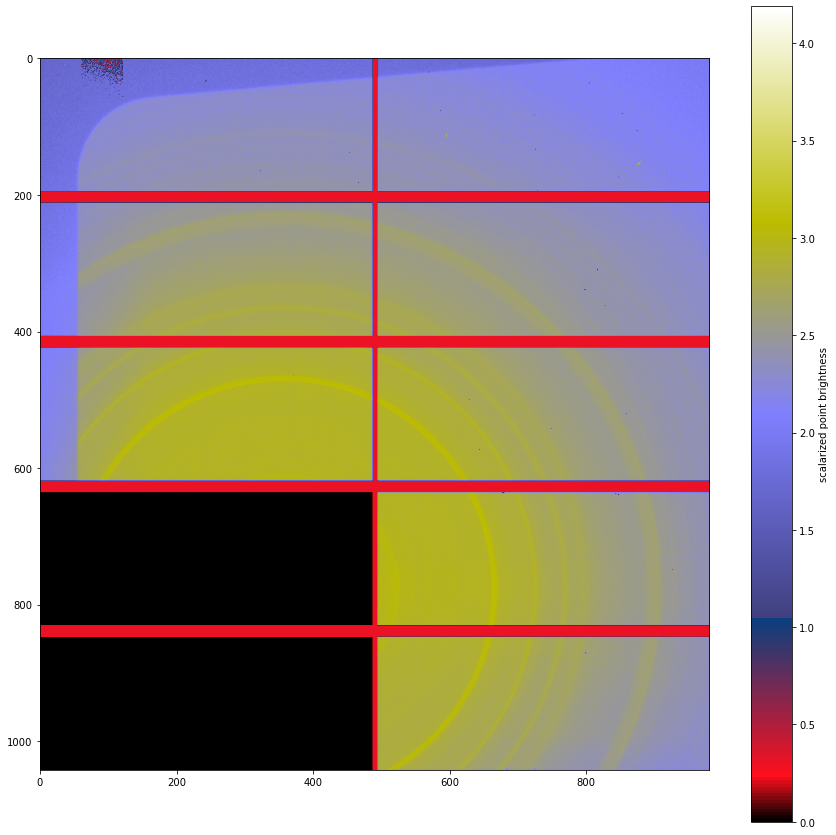

In [247]:
plotter(15)

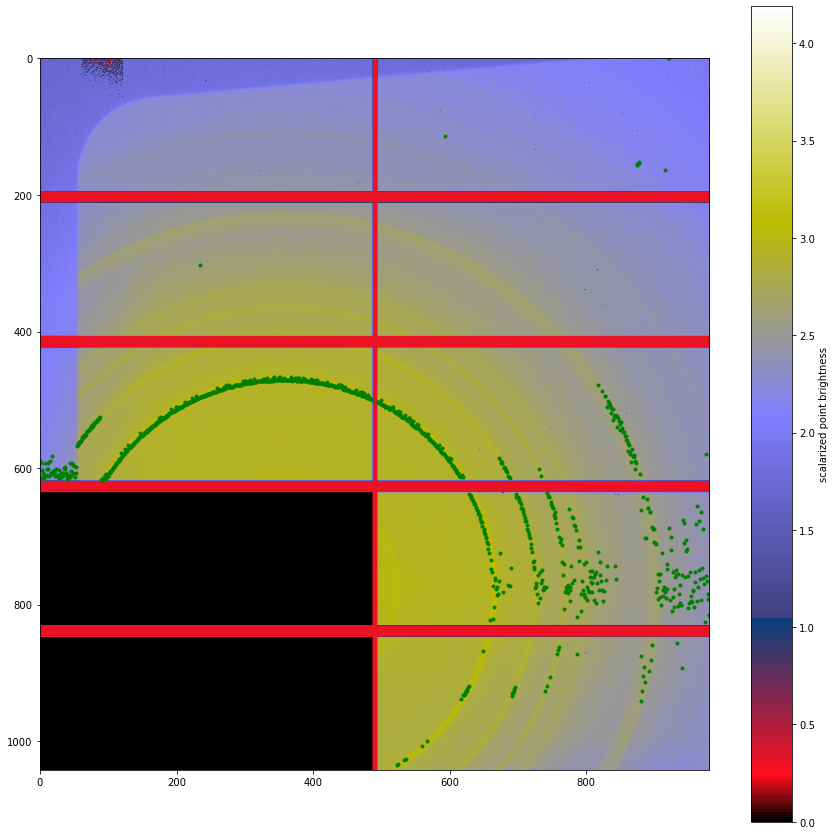

In [248]:
plotter(15) 

save_col=np.array([]) #the elements of this array are just each column in order so 0 to n incrementing by 1
save_row=np.array([])
for b in range(len(img2[0])): #go through every column and note that img2[0] is the size of the number of columns.
    lowerbound=0.999*np.amax(img2[:,b]) #get the actual max value in that column with amax and we want to see where values above this are. The high intensity values. I chose a 99.9% threshold.
    for m in range(len(img2[:,b])): #go through each index of the column
        if (img2[:,b][m]>lowerbound): #if the element is larger than our bound
            save_col=np.append(save_col,b) #get the indicies of the col
            save_row=np.append(save_row,m) #get corresponding row indicies
            plt.plot(b,m,"g.")


'\nplotter(15) \n\nfull_save=np.array_split(cut_down(save_col,save_row), 2)  \nnew_save_col=full_save[0]\nnew_save_row=full_save[1]\n\n\nfor i in range (len(new_save_col)):\n    plt.plot(new_save_col[i],new_save_row[i],"g.")\n'

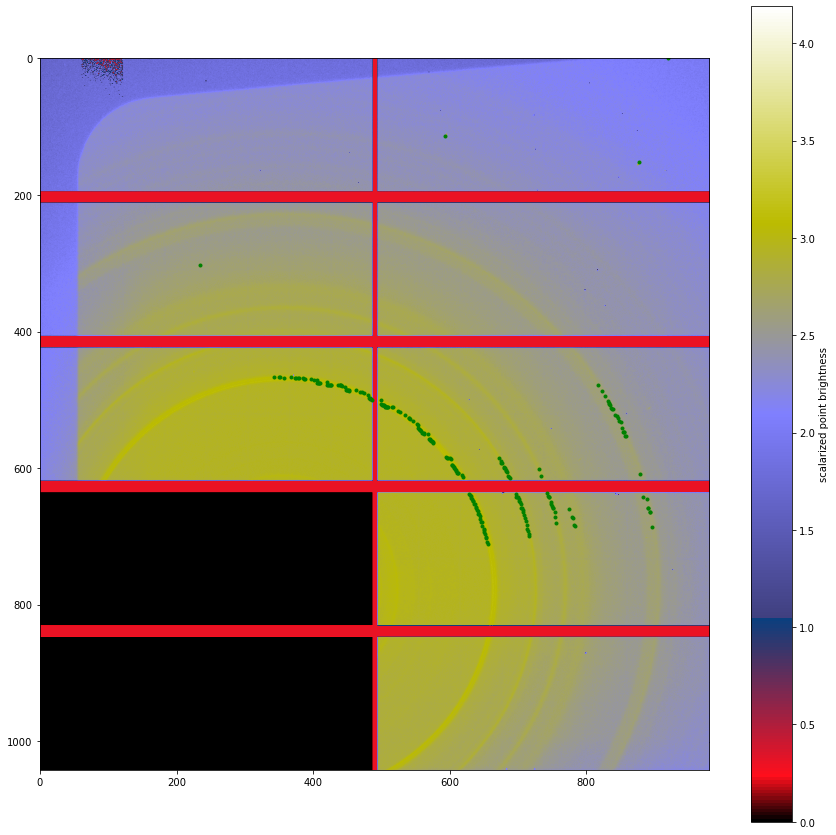

In [253]:
plotter(15) 

full_save=np.array_split(cut_down(save_col,save_row), 2)  
save_col=full_save[0]
save_row=full_save[1]

full_save=np.array_split(cut_down(save_col,save_row), 2)
save_col=full_save[0]
save_row=full_save[1]

full_save=np.array_split(cut_down(save_col,save_row), 2)
save_col=full_save[0]
save_row=full_save[1]

for i in range (len(save_col)):
    plt.plot(save_col[i],save_row[i],"g.")
    


    
'''
plotter(15) 

full_save=np.array_split(cut_down(save_col,save_row), 2)  
new_save_col=full_save[0]
new_save_row=full_save[1]


for i in range (len(new_save_col)):
    plt.plot(new_save_col[i],new_save_row[i],"g.")
'''

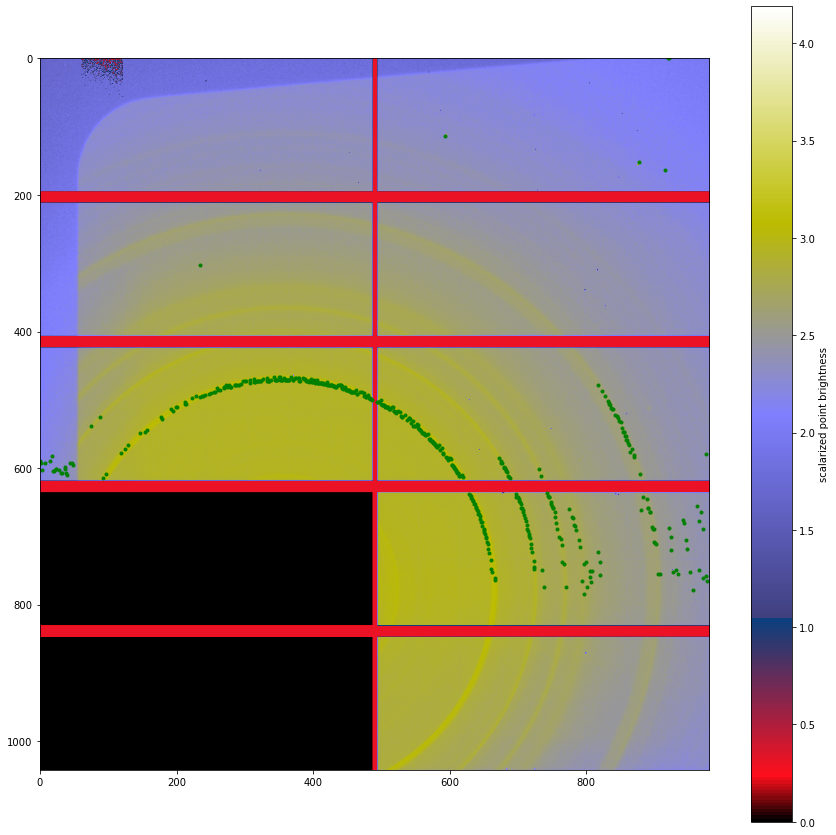

In [250]:
plotter(15) 

full_save2=np.array_split(cut_down(new_save_col,new_save_row), 2)  
new_save_col2=full_save2[0]
new_save_row2=full_save2[1]


for i in range (len(new_save_col2)):
    plt.plot(new_save_col2[i],new_save_row2[i],"g.")

In [175]:
save_row

array([ 589.,  615.,  593.,  603.,  610.,  608.,  614.,  592.,  612.,
        610.,  602.,  602.,  593.,  612.,  609.,  589.,  608.,  609.,
        583.,  604.,  607.,  604.,  606.,  611.,  601.,  601.,  612.,
        610.,  613.,  603.,  615.,  614.,  607.,  613.,  608.,  608.,
        612.,  600.,  599.,  601.,  608.,  616.,  610.,  613.,  610.,
        614.,  592.,  604.,  611.,  593.,  607.,  596.,  597.,  613.,
        607.,  599.,  568.,  566.,  564.,  564.,  562.,  560.,  560.,
        557.,  555.,  554.,  555.,  552.,  551.,  551.,  548.,  546.,
        546.,  544.,  544.,  541.,  541.,  539.,  539.,  540.,  539.,
        536.,  536.,  533.,  533.,  532.,  530.,  531.,  528.,  528.,
        526.,  525.,  618.,  617.,  617.,  614.,  614.,  614.,  610.,
        609.,  616.,  614.,  612.,  612.,  611.,  608.,  608.,  605.,
        604.,  603.,  602.,  600.,  598.,  598.,  596.,  594.,  593.,
        592.,  590.,  589.,  587.,  587.,  586.,  578.,  583.,  581.,
        581.,  579.,